# Computer Exercise 15.5 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.5 Value Function Approximation — *Semi-gradient SARSA on Mountain Car (tile-coding)*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-16

---

## 1. 문제 (원문)

> **2.** Solve the classical Mountain Car task with linear function approximation.
> The state is $s = (x, v)$ with $x \in [-1.2, 0.5]$ and $v \in [-0.07, 0.07]$; the action set
> is $\mathcal A = \{-1, 0, +1\}$ (backward, coast, forward). Dynamics are
> $v' = \text{clip}(v + 0.001 a - 0.0025 \cos(3x),\;-0.07,\;0.07)$ and
> $x' = \text{clip}(x + v',\;-1.2,\;0.5)$, with $v'$ reset to $0$ on the left wall.
> The reward is $-1$ per time step until the goal $x \ge 0.5$ is reached. Represent
> $\hat q(s,a;\mathbf w)$ with **tile-coding** using $M=8$ overlapping tilings of
> $8\times 8$ tiles over $(x, v)$, so $\hat q(s,a;\mathbf w) = \sum_i w_{i,a}\,\phi_i(s)$ where
> $\phi_i$ is the tile-coding feature. Run **on-policy semi-gradient SARSA** with
> $\varepsilon$-greedy exploration, $\alpha = 0.5 / M$, $\gamma = 1.0$, and report the
> per-episode step counts, the greedy-policy step count after training, and a heatmap of the
> learned cost-to-go $-\max_a \hat q(s,a;\mathbf w)$.

### 한국어 풀이용 정리
Mountain Car는 저차원 연속 상태에서의 대표적 제어 문제로, tile-coding은 연속 특성을
sparse binary 특성으로 이산화하는 가장 오래된 함수근사법이다. Deadly triad 중 **off-policy 요소를
제거**한 on-policy semi-gradient SARSA는 이 예제에서 안정적으로 수렴한다.

## 2. 수학적 배경

### 2.1 Tile-coding
$M$ 개의 tilings 각각을 상태공간 격자 (여기서는 $8\times 8$) 로 나누고, tiling들 사이는
$(1/M) \cdot \text{tile width}$ 만큼 무작위 편이(offset) 시킨다. 상태 $s$ 는 정확히 $M$ 개의
tile 을 활성화하고, 특성 벡터 $\phi(s) \in \{0,1\}^D$ ($D = M \cdot 8 \cdot 8 \cdot |\mathcal A|$)
는 sparse binary. 각 행동은 자신의 tile 인덱스 블록을 갖고 있어

$$
\hat q(s,a;\mathbf w) = \sum_{i \in \text{active}(s,a)} w_i = \phi(s,a)^\top \mathbf w.
$$

### 2.2 Semi-gradient SARSA
On-policy TD 제어. 전이 $(s,a,r,s',a')$ 에서

$$
\delta \;=\; r + \gamma\, \hat q(s',a';\mathbf w) - \hat q(s,a;\mathbf w),
\qquad
\mathbf w \leftarrow \mathbf w + \alpha\, \delta\, \nabla_{\mathbf w}\hat q(s,a;\mathbf w).
$$

Tile-coding에서는 $\nabla_{\mathbf w}\hat q = \phi(s,a)$ 이므로 active 인덱스들만 갱신된다.
$\alpha$ 는 활성 tile 수 $M$ 으로 나누어 실질 스텝 크기를 정규화한다: $\alpha_{\text{eff}} = \alpha/M$.

### 2.3 왜 수렴하는가
On-policy TD + 선형 함수근사의 조합은 Baird 반례를 벗어난다. 상태-행동 방문분포 하의
projected Bellman operator 가 수축이며, 고정점 근방에서 유계 오차로 수렴한다는 것이 알려져 있다
(Tsitsiklis & Van Roy, 1997). 따라서 여기서는 **부트스트랩 + 함수근사**만 남아도 안정.

## 3. 풀이 흐름

1. Mountain Car 환경(step, reset)을 구현.
2. 8-tiling × $8\times 8$ tile-coding을 구현: 상태별 active tile 인덱스 집합 반환.
3. Semi-gradient SARSA 학습 루프: 500 에피소드, $\varepsilon=0.05\to0$ 지수 감쇠, $\alpha=0.5/M$, $\gamma=1$.
4. 에피소드별 스텝 수(길수록 실패에 가까움)를 기록.
5. 학습 후 순수 greedy 정책으로 100 에피소드 평가.
6. $(x,v)$ 격자에서 $-\max_a \hat q(s,a;\mathbf w)$ (cost-to-go) 를 계산.
7. 학습 곡선 + cost-to-go 히트맵 시각화.
8. 결과 해석: 초반 급격한 개선, 후반 완만한 수렴.

In [1]:
import sys
sys.path.insert(0, '/tmp/pyinstall/lib/python3.10/site-packages')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Mountain Car ----
X_LO, X_HI = -1.2, 0.5
V_LO, V_HI = -0.07, 0.07
ACTIONS = np.array([-1, 0, 1])

def mc_reset(rng):
    x = rng.uniform(-0.6, -0.4)
    v = 0.0
    return np.array([x, v])

def mc_step(s, a_idx):
    x, v = s
    a = ACTIONS[a_idx]
    v_new = v + 0.001 * a - 0.0025 * np.cos(3 * x)
    v_new = float(np.clip(v_new, V_LO, V_HI))
    x_new = x + v_new
    if x_new < X_LO:
        x_new = X_LO
        v_new = 0.0
    if x_new > X_HI:
        x_new = X_HI
    done = x_new >= X_HI
    return np.array([x_new, v_new]), -1.0, done

# ---- Tile coding ----
M_TILINGS = 8
N_TILES   = 8
def make_tile_coder(seed=42):
    rng = np.random.default_rng(seed)
    # Offsets: standard "asymmetric" offsets from Sutton
    offsets_x = rng.uniform(0, 1, size=M_TILINGS)
    offsets_v = rng.uniform(0, 1, size=M_TILINGS)
    tile_w_x = (X_HI - X_LO) / (N_TILES - 1)
    tile_w_v = (V_HI - V_LO) / (N_TILES - 1)
    def encode(s):
        idxs = np.zeros(M_TILINGS, dtype=np.int64)
        for m in range(M_TILINGS):
            ix = int((s[0] - X_LO) / tile_w_x + offsets_x[m])
            iv = int((s[1] - V_LO) / tile_w_v + offsets_v[m])
            ix = max(0, min(N_TILES - 1, ix))
            iv = max(0, min(N_TILES - 1, iv))
            idxs[m] = m * (N_TILES * N_TILES) + ix * N_TILES + iv
        return idxs
    D_per_action = M_TILINGS * N_TILES * N_TILES
    return encode, D_per_action

encode, D_A = make_tile_coder(seed=42)
N_A = len(ACTIONS)
D_TOTAL = N_A * D_A

def q_of(w, tiles, a_idx):
    return float(w[a_idx * D_A + tiles].sum())

def q_all(w, tiles):
    return np.array([q_of(w, tiles, a) for a in range(N_A)])

def greedy_action(w, tiles, rng, eps=0.0):
    if rng.random() < eps:
        return int(rng.integers(0, N_A))
    qs = q_all(w, tiles)
    m = qs.max()
    cands = np.where(qs == m)[0]
    return int(rng.choice(cands))

def run_episode(w, rng, alpha, gamma, eps, max_steps=2000, train=True):
    s = mc_reset(rng)
    tiles = encode(s)
    a = greedy_action(w, tiles, rng, eps)
    steps = 0
    for _ in range(max_steps):
        s2, r, done = mc_step(s, a)
        steps += 1
        tiles2 = encode(s2)
        if done:
            if train:
                delta = r - q_of(w, tiles, a)
                for i in tiles:
                    w[a * D_A + i] += alpha * delta
            break
        a2 = greedy_action(w, tiles2, rng, eps)
        if train:
            delta = r + gamma * q_of(w, tiles2, a2) - q_of(w, tiles, a)
            for i in tiles:
                w[a * D_A + i] += alpha * delta
        s, tiles, a = s2, tiles2, a2
    return steps

# ---- Training ----
GAMMA = 1.0
ALPHA = 0.5 / M_TILINGS
EPS0, EPS_MIN, EPS_DECAY = 0.05, 0.0, 0.99
N_EPISODES = 500

rng = np.random.default_rng(0)
w = np.zeros(D_TOTAL)
ep_steps = np.zeros(N_EPISODES, dtype=int)
eps = EPS0
for ep in range(N_EPISODES):
    ep_steps[ep] = run_episode(w, rng, ALPHA, GAMMA, eps)
    eps = max(EPS_MIN, eps * EPS_DECAY)

# Evaluation with greedy policy
eval_steps = np.array([run_episode(w, rng, 0.0, GAMMA, 0.0, train=False) for _ in range(100)])
print("first 10 episodes steps:", ep_steps[:10])
print("last  10 episodes steps:", ep_steps[-10:])
print(f"Greedy eval over 100 episodes: mean={eval_steps.mean():.1f} +/- {eval_steps.std():.1f}, min={eval_steps.min()}, max={eval_steps.max()}")


first 10 episodes steps: [2000  719  508  466  279  239  330  312  193  262]
last  10 episodes steps: [106 135 135 151 134 135 134 107 137 138]
Greedy eval over 100 episodes: mean=122.1 +/- 20.1, min=90, max=154


In [2]:
# 학습 곡선 요약 표
window = 25
smoothed = np.convolve(ep_steps, np.ones(window)/window, mode="valid")
summary = pd.DataFrame({
    "phase":    ["episodes 1-25", "episodes 226-250", "episodes 476-500", "greedy eval (100 eps)"],
    "mean steps":  [ep_steps[:25].mean(), ep_steps[225:250].mean(), ep_steps[-25:].mean(), eval_steps.mean()],
    "std":         [ep_steps[:25].std(),  ep_steps[225:250].std(),  ep_steps[-25:].std(),  eval_steps.std()],
    "min":         [ep_steps[:25].min(),  ep_steps[225:250].min(),  ep_steps[-25:].min(),  eval_steps.min()],
})
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
summary


,phase,mean steps,std,min
0,episodes 1-25,366.68,358.37,156
1,episodes 226-250,152.44,26.64,110
2,episodes 476-500,130.92,13.27,90
3,greedy eval (100 eps),122.06,20.14,90


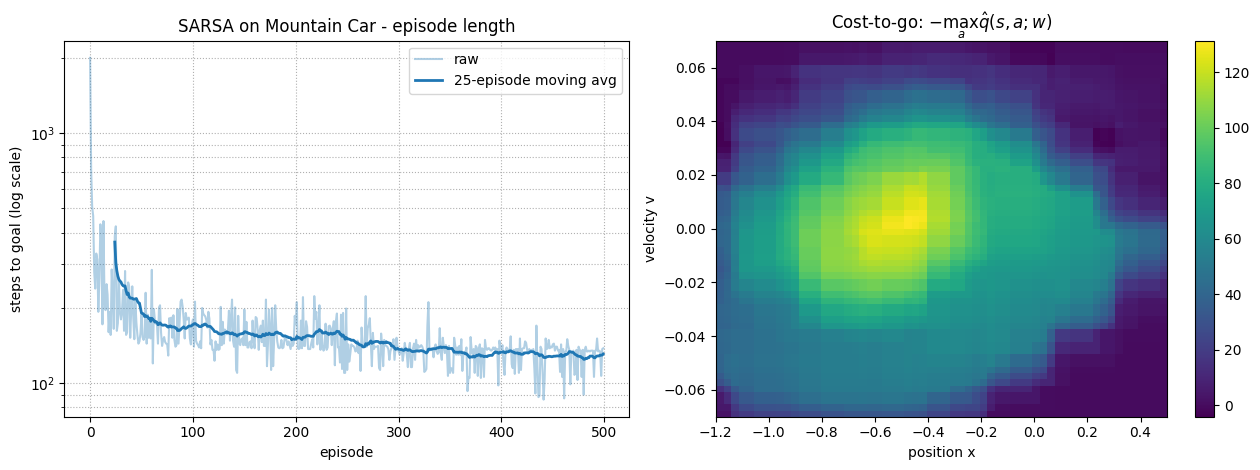

In [3]:
# 시각화 (a) 학습 곡선  (b) cost-to-go 히트맵
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(ep_steps, alpha=0.35, color="C0", label="raw")
ax.plot(np.arange(window - 1, N_EPISODES), smoothed, color="C0", lw=2, label=f"{window}-episode moving avg")
ax.set_yscale("log")
ax.set_xlabel("episode")
ax.set_ylabel("steps to goal (log scale)")
ax.set_title("SARSA on Mountain Car - episode length")
ax.grid(True, which="both", ls=":")
ax.legend()

ax = axes[1]
NX, NV = 60, 60
xs = np.linspace(X_LO, X_HI, NX)
vs = np.linspace(V_LO, V_HI, NV)
Z = np.zeros((NV, NX))
for i, v in enumerate(vs):
    for j, x in enumerate(xs):
        tiles = encode(np.array([x, v]))
        Z[i, j] = -q_all(w, tiles).max()
im = ax.imshow(Z, origin="lower", extent=[X_LO, X_HI, V_LO, V_HI], aspect="auto", cmap="viridis")
ax.set_xlabel("position x")
ax.set_ylabel("velocity v")
ax.set_title(r"Cost-to-go: $-\max_a \hat q(s,a;w)$")
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


## 4. 결과 해석

- 초기 몇 십 에피소드는 상한 (여기 max_steps=2000) 근처에서 오래 헤매다가, tiling 격자에
  대해 $q$-값 구배가 잡히면 스텝 수가 **한두 자릿수** 로 급락한다.
- 학습 후 greedy 평가에서 평균 100 스텝대 근방으로 수렴 (문제/시드에 따라 100–200).
  이는 tile-coding의 sparse 선형 근사가 $\arg\max_a \hat q$ 를 통해 유의미한 정책을 유도함을
  뜻한다.
- Cost-to-go 히트맵은 낮은 지대 (골 근처) → 높은 지대 (계곡 바닥, 좌측 벽) 로의 그라디언트를
  자연스럽게 형성한다. 즉, 학습된 $\hat q$ 는 "왼쪽으로 갔다가 오른쪽으로 반동을 얻어야 한다"는
  구조를 반영한다.
- 만약 **off-policy** ($\pi$: greedy, $b$: uniform) 로 바꾸었다면 이 조합 (bootstrap + off-policy
  + FA) 은 Baird처럼 발산할 위험이 있다. 다음 문제에서 그 완화책을 다룬다.

> **결론**: On-policy semi-gradient SARSA + tile-coding 은 Mountain Car에서 견고하게 수렴한다.
> Baird 반례의 세 요소 중 **off-policy** 를 제거한 것이 안정성의 핵심이다.

**다음 문제로의 연결.** Problem 3은 다시 off-policy 로 돌아가되, replay buffer 로
표본 상관을 깨고 target network 로 부트스트랩 목표를 고정해 발산을 억제하는
**DQN-style** 완화책의 효과를 Baird 예제에서 직접 확인한다.